# Classification Model Comparison

This notebook compares classification models for predicting `HealthImpactClass`, a categorical health outcome variable.

The models include:
- Multiclass Logistic Regression
- Lasso-Regularized Logistic Regression
- K-Nearest Neighbors (KNN)

We use stratified 10-fold cross-validation because the target classes are imbalanced.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

sns.set_theme(style="whitegrid")

### Dataset

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "air_quality_health_impact_data.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,RecordID,AQI,PM10,PM2_5,NO2,SO2,O3,Temperature,Humidity,WindSpeed,RespiratoryCases,CardiovascularCases,HospitalAdmissions,HealthImpactScore,HealthImpactClass
0,1,187.270059,295.853039,13.038560,6.639263,66.161150,54.624280,5.150335,84.424344,6.137755,7,5,1,97.244041,0.0
1,2,475.357153,246.254703,9.984497,16.318326,90.499523,169.621728,1.543378,46.851415,4.521422,10,2,0,100.000000,0.0
2,3,365.996971,84.443191,23.111340,96.317811,17.875850,9.006794,1.169483,17.806977,11.157384,13,3,0,100.000000,0.0
3,4,299.329242,21.020609,14.273403,81.234403,48.323616,93.161033,21.925276,99.473373,15.302500,8,8,1,100.000000,0.0
4,5,78.009320,16.987667,152.111623,121.235461,90.866167,241.795138,9.217517,24.906837,14.534733,9,0,1,95.182643,0.0


## Class Distribution

Before modeling, we examine the number of records in each class. 

How to read the output:
- Each number represents one `HealthImpactClass`.
- A larger count means that more records belong to that class.
- If one class has many more records than the others, the dataset is imbalanced.

Because distribution shows that `HealthImpactClass` is imbalanced with most observations in class **0**, we randomly choose 650 samples from class 0 to reduce imbalanced. This value was chosen to be comparable to the size of the second-largest class while retaining sufficient training data. Models were then evaluated using Accuracy, Balanced Accuracy, and Macro F1-score, with Macro F1 serving as the primary metric because it gives equal weight to each class.

In [3]:
class_0 = df[df['HealthImpactClass'] == 0]
other_classes = df[df['HealthImpactClass'] != 0]

class_0_sampled = class_0.sample(n=650, random_state=42)
df_balanced = pd.concat([class_0_sampled, other_classes], ignore_index=True)

## Define Predictors and Target

The target variable is `HealthImpactClass`.

We exclude:
- `RecordID`, because it is only an identifier.
- `HealthImpactScore`, because it is closely related to the class label and could cause target leakage.
- Health-related case counts, because this analysis focuses on whether environmental conditions predict the health impact class.

In [4]:
predictors = [
    "AQI",
    "PM10",
    "PM2_5",
    "NO2",
    "SO2",
    "O3",
    "Temperature",
    "Humidity",
    "WindSpeed"
]

X = df_balanced[predictors]
y = df_balanced["HealthImpactClass"].astype(int)

print("Predictor shape:", X.shape)
print("Target shape:", y.shape)

Predictor shape: (1653, 9)
Target shape: (1653,)


In [5]:
class_counts = y.value_counts().sort_index()
class_counts

HealthImpactClass
0    650
1    579
2    273
3     95
4     56
Name: count, dtype: int64

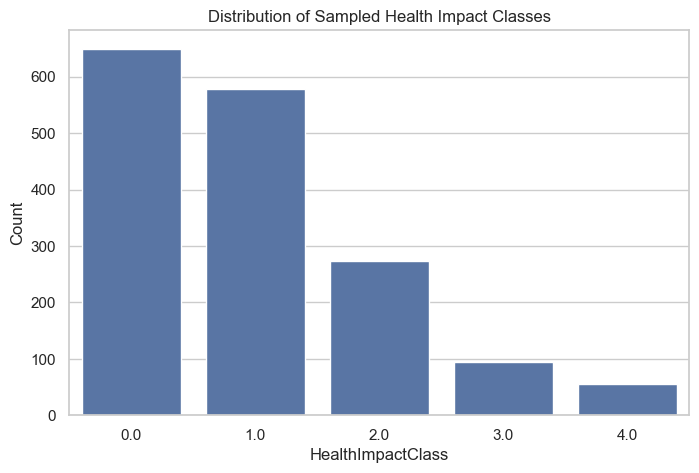

In [6]:
plt.figure(figsize = (8, 5))
sns.countplot(data = df_balanced, x = "HealthImpactClass", order = sorted(df_balanced["HealthImpactClass"].unique()))
plt.title("Distribution of Sampled Health Impact Classes")
plt.xlabel("HealthImpactClass")
plt.ylabel("Count")
plt.show()

Although after sampled from original dataset, it is still hard to make it balanced. For this reason, accuracy alone may be misleading. We will also use balanced accuracy, macro F1-score, classification reports, and confusion matrices.

## Train/Test Split and Cross-Validation

We reserve 20% of the data as a final test set. We use stratification so that the class proportions remain similar in the training and testing sets.

Within the training set, we use stratified 10-fold cross-validation.

How to read the metrics:
- `Accuracy` is the percentage of predictions that are correct.
- `Balanced accuracy` gives equal importance to each class. This is useful when classes are imbalanced.
- `Macro F1-score` calculates the F1-score for each class and gives each class equal weight. Higher values are better.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro": "f1_macro"
}

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 1322
Testing rows: 331


In [8]:
def cross_validation_summary(model_name, model):
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    return {
        "Model": model_name,
        "Mean CV Accuracy": scores["test_accuracy"].mean(),
        "Mean CV Balanced Accuracy": scores["test_balanced_accuracy"].mean(),
        "Mean CV Macro F1": scores["test_f1_macro"].mean()
    }


def test_summary(model_name, model):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    return {
        "Model": model_name,
        "Test Accuracy": accuracy_score(y_test, predictions),
        "Test Balanced Accuracy": balanced_accuracy_score(y_test, predictions),
        "Test Macro F1": f1_score(y_test, predictions, average="macro")
    }

## Multiclass Logistic Regression Baseline

Logistic Regression provides a baseline classification model. We use balanced class weights so that smaller classes receive more attention during training.

In [9]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(
        max_iter=5000,
        class_weight="balanced"
    ))
])

logistic_cv = cross_validation_summary(
    "Logistic Regression",
    logistic_model
)

pd.DataFrame([logistic_cv])

,Model,Mean CV Accuracy,Mean CV Balanced Accuracy,Mean CV Macro F1
0,Logistic Regression,0.467538,0.363791,0.351971


## Lasso-Regularized Logistic Regression

Lasso regularization can reduce the influence of weaker predictors. In Logistic Regression, the regularization strength is controlled by `C`.

How to read `C`:
- Smaller `C` values apply stronger regularization.
- Larger `C` values apply weaker regularization.
- The best `C` value is selected using macro F1-score because the classes are imbalanced.

In [10]:
lasso_logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ovr", OneVsRestClassifier(
        LogisticRegression(
            solver="liblinear",
            l1_ratio=1,
            max_iter=5000,
            class_weight="balanced",
            random_state=42
        )
    ))
])

lasso_logistic_search = GridSearchCV(
    estimator=lasso_logistic_pipeline,
    param_grid={
        "ovr__estimator__C": [0.01, 0.1, 1, 10, 100]
    },
    scoring="f1_macro",
    cv=cv,
    n_jobs=1
)

lasso_logistic_search.fit(X_train, y_train)

print("Best C:", lasso_logistic_search.best_params_["ovr__estimator__C"])
print("Best CV Macro F1:", lasso_logistic_search.best_score_)

Best C: 10
Best CV Macro F1: 0.340479591168803


In [11]:
lasso_logistic_results = pd.DataFrame({
    "C": lasso_logistic_search.cv_results_["param_ovr__estimator__C"].astype(float),
    "Mean CV Macro F1": lasso_logistic_search.cv_results_["mean_test_score"]
}).sort_values("C")

lasso_logistic_results

,C,Mean CV Macro F1
0,0.01,0.286104
1,0.10,0.333331
2,1.00,0.340230
3,10.00,0.340480
4,100.00,0.340117


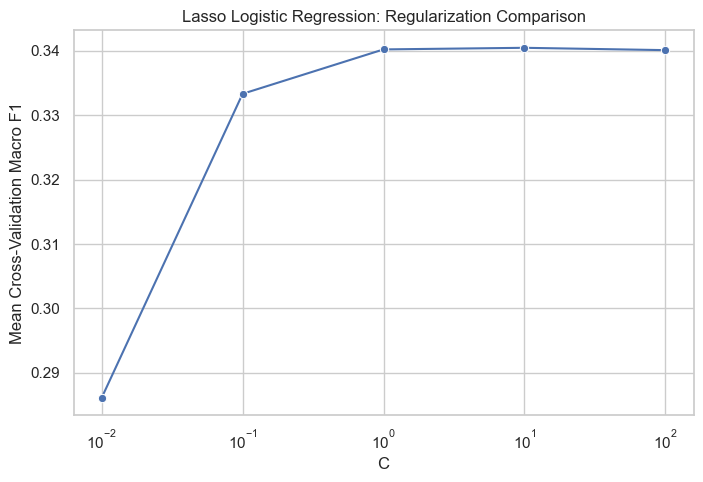

In [12]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=lasso_logistic_results, x="C", y="Mean CV Macro F1", marker="o")
plt.xscale("log")
plt.title("Lasso Logistic Regression: Regularization Comparison")
plt.xlabel("C")
plt.ylabel("Mean Cross-Validation Macro F1")
plt.show()

## K-Nearest Neighbors

KNN classifies each record based on nearby records with similar predictor values. Scaling is important because the environmental predictors use different units.

We compare several values of `k`, the number of neighbors:
- Smaller values can create a more flexible model.
- Larger values create smoother decision boundaries.
- The best `k` value is selected using macro F1-score.

In [13]:
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

knn_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid={
        "knn__n_neighbors": [3, 5, 7, 11, 15, 21],
        "knn__weights": ["uniform", "distance"]
    },
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)

knn_search.fit(X_train, y_train)

print("Best parameters:", knn_search.best_params_)
print("Best CV Macro F1:", knn_search.best_score_)

Best parameters: {'knn__n_neighbors': 7, 'knn__weights': 'distance'}
Best CV Macro F1: 0.35703281164749123


In [14]:
knn_results = pd.DataFrame({
    "Neighbors": knn_search.cv_results_["param_knn__n_neighbors"].astype(int),
    "Weights": knn_search.cv_results_["param_knn__weights"],
    "Mean CV Macro F1": knn_search.cv_results_["mean_test_score"]
}).sort_values(["Weights", "Neighbors"])

knn_results

,Neighbors,Weights,Mean CV Macro F1
1,3,distance,0.355357
3,5,distance,0.355318
5,7,distance,0.357033
7,11,distance,0.348717
9,15,distance,0.331186
11,21,distance,0.329626
0,3,uniform,0.346977
2,5,uniform,0.343420
4,7,uniform,0.346118
6,11,uniform,0.334405


## Final Model Comparison

This section compares the final performance of each model on the held-out test set.

Because the classes are imbalanced, balanced accuracy and macro F1-score are more informative than accuracy alone.

In [15]:
best_models = {
    "Logistic Regression": logistic_model,
    "Lasso Logistic Regression": lasso_logistic_search.best_estimator_,
    "K-Nearest Neighbors": knn_search.best_estimator_
}

comparison_results = pd.DataFrame([
    test_summary(model_name, model)
    for model_name, model in best_models.items()
]).sort_values("Test Macro F1", ascending=False)

comparison_results

,Model,Test Accuracy,Test Balanced Accuracy,Test Macro F1
0,Logistic Regression,0.468278,0.362625,0.361735
1,Lasso Logistic Regression,0.586103,0.357372,0.354628
2,K-Nearest Neighbors,0.619335,0.365291,0.353466


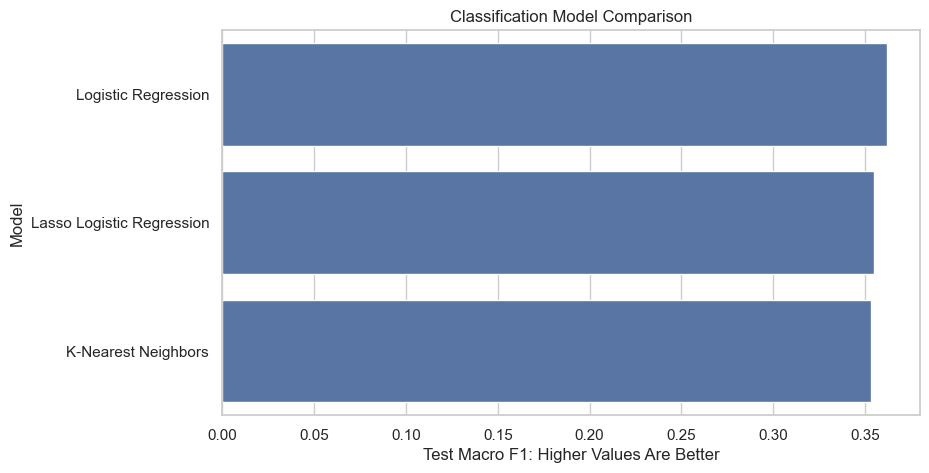

In [16]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=comparison_results,
    x="Test Macro F1",
    y="Model"
)
plt.title("Classification Model Comparison")
plt.xlabel("Test Macro F1: Higher Values Are Better")
plt.ylabel("Model")
plt.show()

## Classification Report and Confusion Matrix

This section examines the best-performing model in more detail.

How to read the classification report:
- `Precision` measures how often predictions for a class are correct.
- `Recall` measures how often the model identifies records that belong to a class.
- `F1-score` balances precision and recall.
- `Support` shows the number of test records in each class.

How to read the confusion matrix:
- Rows represent actual classes.
- Columns represent predicted classes.
- Values on the diagonal represent correct predictions.

In [17]:
best_model_name = comparison_results.iloc[0]["Model"]
best_model = best_models[best_model_name]

best_model.fit(X_train, y_train)
best_predictions = best_model.predict(X_test)

print("Best model:", best_model_name)
print()
print(classification_report(y_test, best_predictions, zero_division=0))

Best model: Logistic Regression

              precision    recall  f1-score   support

           0       0.79      0.44      0.56       130
           1       0.66      0.53      0.59       116
           2       0.49      0.60      0.54        55
           3       0.05      0.16      0.08        19
           4       0.02      0.09      0.04        11

    accuracy                           0.47       331
   macro avg       0.40      0.36      0.36       331
weighted avg       0.63      0.47      0.52       331



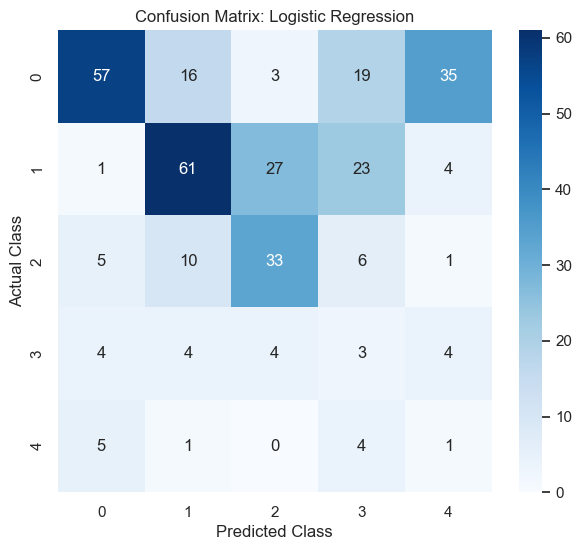

In [18]:
matrix = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(7, 6))
sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

In [19]:
final_logistic_model = lasso_logistic_search.best_estimator_
final_logistic_model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('ovr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegre...r='liblinear')
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'mul

In [20]:
classes = final_logistic_model.named_steps["ovr"].classes_

coef_df = pd.DataFrame(
    final_logistic_model.named_steps["ovr"].estimators_[0].coef_,
    columns=predictors
)

coef_df.index = [f"Class {classes[0]}"]

for i in range(1, len(classes)):
    temp = pd.DataFrame(
        final_logistic_model.named_steps["ovr"].estimators_[i].coef_,
        columns=predictors
    )
    temp.index = [f"Class {classes[i]}"]
    coef_df = pd.concat([coef_df, temp])

coef_df

,AQI,PM10,PM2_5,NO2,SO2,O3,Temperature,Humidity,WindSpeed
Class 0,1.546230,0.454547,0.616545,0.436573,0.067456,0.370715,-0.013586,-0.027452,0.069096
Class 1,-1.337458,-0.114977,-0.038654,-0.116199,-0.063695,-0.067391,-0.039180,0.153167,-0.041317
Class 2,-0.570373,-0.366166,-0.614991,-0.232697,-0.012165,-0.307502,0.080362,-0.133047,0.021367
Class 3,0.061121,-0.236728,-0.379859,-0.202181,-0.081215,-0.290667,0.009461,-0.069857,-0.010563
Class 4,0.598889,0.301101,0.103312,-0.089378,0.216526,0.110505,0.094181,0.134426,-0.228506


In [21]:
importance = pd.DataFrame({
    "Feature": predictors,
    "Mean_Abs_Coefficient":
        np.mean(np.abs(coef_df.values), axis=0)
})
importance = importance.sort_values(
    "Mean_Abs_Coefficient",
    ascending=False
)
importance

,Feature,Mean_Abs_Coefficient
0,AQI,0.822815
2,PM2_5,0.350672
1,PM10,0.294704
5,O3,0.229356
3,NO2,0.215406
7,Humidity,0.103590
4,SO2,0.088211
8,WindSpeed,0.074170
6,Temperature,0.047354


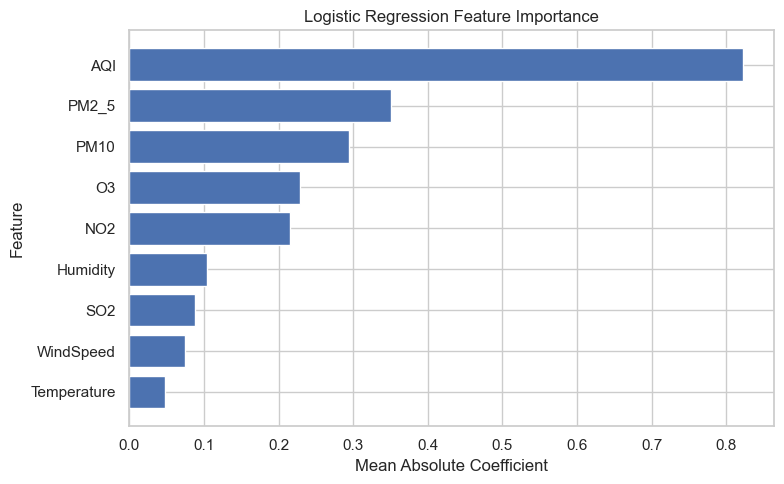

In [22]:
plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"][::-1],
    importance["Mean_Abs_Coefficient"][::-1]
)

plt.xlabel("Mean Absolute Coefficient")
plt.ylabel("Feature")
plt.title("Logistic Regression Feature Importance")
plt.tight_layout()
plt.show()

Although KNN achieved the highest cross-validated macro F1 score and was selected as the final predictive model, Logistic Regression coefficients were examined for interpretability. AQI, PM2.5, and NO2 exhibited the largest absolute coefficients, indicating they are among the most influential predictors of Health Impact Class.

## Conclusions

After balancing the dataset by randomly downsampling the majority class (`HealthImpactClass = 0`), the classification models were evaluated on a more representative distribution of health impact categories. This allowed model performance to better reflect their ability to distinguish between different health impact levels rather than primarily predicting the majority class.

Among the models tested, KNN achieved the highest test accuracy (0.619) and balanced accuracy (0.365), while **Logistic Regression** achieved the highest macro F1-score (0.362). Because macro F1 places equal importance on all classes, **Logistic Regression** demonstrated the most balanced performance across the health impact categories and was therefore selected as the best overall classification model.

Lasso-Regularized Logistic Regression achieved higher overall accuracy than the baseline Logistic Regression but did not improve balanced accuracy or macro F1-score. This suggests that regularization did not substantially improve the model's ability to distinguish between the different health impact classes.

Overall, the results indicate that air quality and weather variables contain meaningful information for predicting health impact severity. However, the relatively modest balanced accuracy and macro F1-scores suggest that predicting multiple health impact categories remains a challenging task. The findings support the hypothesis that environmental conditions are associated with health outcomes, while also highlighting the complexity of accurately classifying health impact levels using environmental factors alone.
